In [1]:
# make sure you installed the mnist1d package

%load_ext autoreload
%autoreload 2
import torch
from a02_functions import SimpleCNN, SimpleMLP, train_model
from a02_helper import (
    plot_templates,
    get_raw_data,
    count_model_params,
    shuffle_pixels,
    plot_example,
    nextplot,
)

# Task 2: MNIST-1D
### Dataset

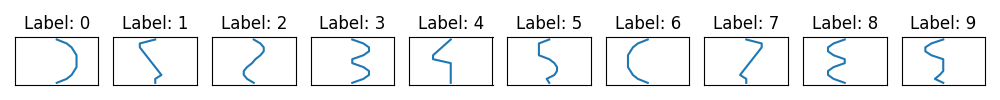

In [2]:
# Those are the templates that the examples in the dataset are based on.
nextplot()
plot_templates()

In [3]:
data = get_raw_data()

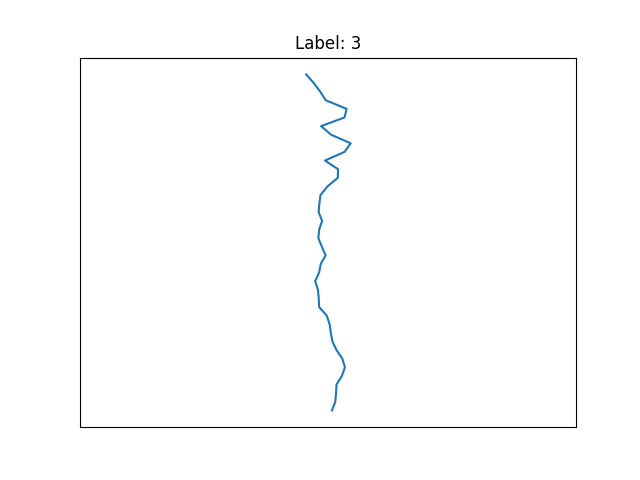

In [4]:
idx = 8
x, y, t = data["x"][idx], data["y"][idx], data["t"]
nextplot()
plot_example(x, y, t)

### Model

Verify your model's implementation by running the following test cases.

In [5]:
torch.manual_seed(0)
cnn = SimpleCNN()
x_unbatched = torch.ones(40)
x_batched = x_unbatched.view(1, -1)
with torch.no_grad():  # these should give no error
    y_batched = cnn(x_batched)
    y_unbatched = cnn(x_unbatched)

x_batched, x_unbatched  # these are the inputs being used

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1.]]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.]))

Initialize your model and verify the total number of parameters computed by
hand.

In [6]:
torch.manual_seed(0)
cnn = SimpleCNN()
print(cnn)
print(f"No. of parameters: {count_model_params(cnn)}")

SimpleCNN(
  (conv1): Conv1d(1, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv2): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv3): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv4): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (fc): Linear(in_features=25, out_features=10, bias=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
No. of parameters: 6060


### Training

Train your model.

In [7]:
results = train_model(data, cnn)

epoch 0, dt 1.26s, train_loss 1.516e+00, val_loss 1.446e+00, train_acc 40.9, val_acc 40.9


epoch 10, dt 5.78s, train_loss 5.429e-01, val_loss 7.628e-01, train_acc 78.3, val_acc 69.6


epoch 20, dt 5.75s, train_loss 1.439e-01, val_loss 5.125e-01, train_acc 94.6, val_acc 85.2


epoch 30, dt 5.66s, train_loss 2.544e-01, val_loss 6.618e-01, train_acc 94.9, val_acc 84.1


epoch 40, dt 5.66s, train_loss 7.192e-02, val_loss 5.300e-01, train_acc 98.9, val_acc 88.8


...

epoch 60, dt 5.65s, train_loss 2.567e-02, val_loss 6.940e-01, train_acc 98.2, val_acc 88.6


epoch 70, dt 5.65s, train_loss 7.443e-02, val_loss 6.078e-01, train_acc 98.4, val_acc 89.4


epoch 80, dt 5.66s, train_loss 5.132e-02, val_loss 6.660e-01, train_acc 97.9, val_acc 87.1


epoch 90, dt 5.70s, train_loss 2.976e-02, val_loss 5.173e-01, train_acc 99.8, val_acc 89.5


Final result: train_loss 1.168e-03, val_loss 5.173e-01, test_loss 5.381e-01, train_acc 99.8, val_acc 89.5, test_acc 91.2


### Simple Feedforward Neural Network

Compare the results of the CNN and FNN models (after your conjecture!).

In [8]:
torch.manual_seed(0)
fnn = SimpleMLP()
print(f"No. of parameters: {count_model_params(fnn)}")

No. of parameters: 78858


In [9]:
results = train_model(data, fnn)

epoch 0, dt 0.06s, train_loss 1.584e+00, val_loss 1.562e+00, train_acc 46.2, val_acc 39.9


epoch 10, dt 0.56s, train_loss 5.460e-01, val_loss 1.470e+00, train_acc 85.6, val_acc 56.6


epoch 20, dt 0.55s, train_loss 1.636e-01, val_loss 2.098e+00, train_acc 94.8, val_acc 59.9


epoch 30, dt 0.55s, train_loss 1.725e-01, val_loss 2.681e+00, train_acc 96.1, val_acc 61.9


epoch 40, dt 0.54s, train_loss 1.638e-01, val_loss 3.435e+00, train_acc 98.8, val_acc 61.2


...

epoch 60, dt 0.55s, train_loss 3.195e-04, val_loss 3.229e+00, train_acc 100.0, val_acc 64.0


epoch 70, dt 0.56s, train_loss 1.885e-04, val_loss 3.271e+00, train_acc 100.0, val_acc 64.1


epoch 80, dt 0.56s, train_loss 2.504e-04, val_loss 3.315e+00, train_acc 100.0, val_acc 63.9


epoch 90, dt 0.54s, train_loss 9.737e-05, val_loss 3.358e+00, train_acc 100.0, val_acc 64.1


Final result: train_loss 1.113e-04, val_loss 3.358e+00, test_loss 2.895e+00, train_acc 100.0, val_acc 64.1, test_acc 64.2


### Shuffled Dataset

Shuffle the dataset along the spatial dimension.

In [10]:
shuffled_dataset = shuffle_pixels(data)

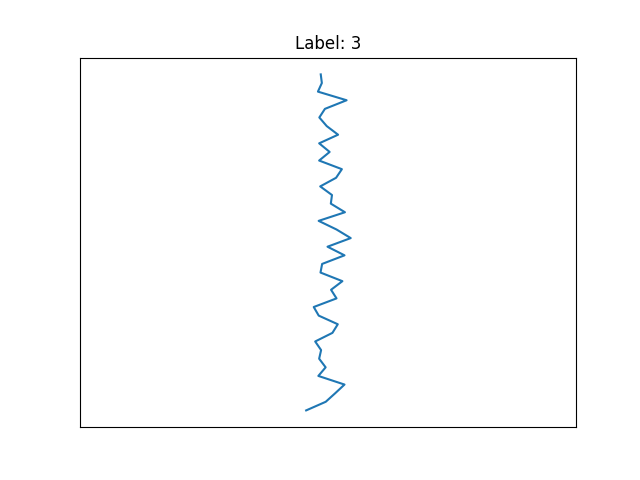

In [11]:
idx = 8
x, y, t = shuffled_dataset["x"][idx], shuffled_dataset["y"][idx], shuffled_dataset["t"]
nextplot()
plot_example(x, y, t)

In [12]:
torch.manual_seed(0)
cnn = SimpleCNN()
results = train_model(shuffled_dataset, cnn)

epoch 0, dt 0.64s, train_loss 1.723e+00, val_loss 1.673e+00, train_acc 32.4, val_acc 32.5


epoch 10, dt 5.67s, train_loss 1.005e+00, val_loss 1.248e+00, train_acc 60.0, val_acc 53.5


epoch 20, dt 5.67s, train_loss 7.293e-01, val_loss 1.340e+00, train_acc 71.3, val_acc 54.1


epoch 30, dt 5.67s, train_loss 6.216e-01, val_loss 1.533e+00, train_acc 78.9, val_acc 56.0


epoch 40, dt 5.80s, train_loss 4.693e-01, val_loss 1.964e+00, train_acc 75.2, val_acc 54.8


...

epoch 60, dt 5.72s, train_loss 4.436e-01, val_loss 2.224e+00, train_acc 87.1, val_acc 57.0


epoch 70, dt 5.67s, train_loss 2.943e-01, val_loss 2.781e+00, train_acc 90.5, val_acc 57.0


epoch 80, dt 5.69s, train_loss 5.889e-01, val_loss 2.885e+00, train_acc 90.8, val_acc 56.9


epoch 90, dt 5.66s, train_loss 5.850e-01, val_loss 3.013e+00, train_acc 86.3, val_acc 55.1


Final result: train_loss 3.150e-01, val_loss 3.013e+00, test_loss 3.365e+00, train_acc 86.3, val_acc 55.1, test_acc 55.4


In [13]:
torch.manual_seed(0)
fnn = SimpleMLP()
results = train_model(shuffled_dataset, fnn)


# # %%
# # Self verify code 2c - can delete later
# from a02_functions import SimpleCNN
# from a02_helper import count_model_params

# model = SimpleCNN(channels=5, kernel_size=3, stride=2, padding=1, linear_in=5)
# print(count_model_params(model))  # should print 320

epoch 0, dt 0.06s, train_loss 1.593e+00, val_loss 1.561e+00, train_acc 46.6, val_acc 40.5


epoch 10, dt 0.54s, train_loss 4.823e-01, val_loss 1.490e+00, train_acc 82.1, val_acc 59.0


epoch 20, dt 0.53s, train_loss 1.039e-01, val_loss 1.820e+00, train_acc 96.0, val_acc 62.6


epoch 30, dt 0.54s, train_loss 4.441e-02, val_loss 2.445e+00, train_acc 99.2, val_acc 62.9


epoch 40, dt 0.54s, train_loss 1.979e-03, val_loss 2.314e+00, train_acc 100.0, val_acc 65.0


...

epoch 60, dt 0.54s, train_loss 6.266e-04, val_loss 2.466e+00, train_acc 100.0, val_acc 65.4


epoch 70, dt 0.53s, train_loss 3.114e-04, val_loss 2.533e+00, train_acc 100.0, val_acc 65.0


epoch 80, dt 0.53s, train_loss 2.981e-04, val_loss 2.601e+00, train_acc 100.0, val_acc 64.9


epoch 90, dt 0.53s, train_loss 1.804e-04, val_loss 2.665e+00, train_acc 100.0, val_acc 64.6


Final result: train_loss 1.522e-04, val_loss 2.665e+00, test_loss 2.760e+00, train_acc 100.0, val_acc 64.6, test_acc 65.1
